# Football Player Value Analysis — 2022-23 Season
**Question:** Which players in the top 5 European leagues deliver the most value relative to their market price, judged fairly within their own position?

**Leagues:** Premier League · Bundesliga · La Liga · Serie A · Ligue 1  
**Data sources:** [2022-2023 Player Stats](https://www.kaggle.com/datasets/vivovinco/20222023-football-player-stats) (via Kaggle) · [Transfermarkt valuations](https://www.kaggle.com/datasets/davidcariboo/player-scores) (davidcariboo/player-scores)  
**Valuation anchor:** 2023-05-31 — end of season, before the summer transfer window

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

DB_PATH = Path('../data/football.db')
conn = sqlite3.connect(DB_PATH)
print('Connected to', DB_PATH)

Connected to ../data/football.db


---
## 1. Data Loading & Validation

In [2]:
# Load raw sources for shape checks
stats_raw = pd.read_csv('../data/player_stats.csv', encoding='latin-1', sep=';')
vals_raw  = pd.read_csv('../data/player_valuations.csv')
bridge    = pd.read_csv('../archive (3)/players.csv')[['player_id', 'name']]

print(f'player_stats.csv  : {stats_raw.shape[0]:,} rows, {stats_raw.shape[1]} cols')
print(f'player_valuations : {vals_raw.shape[0]:,} rows')
print(f'players_bridge    : {bridge.shape[0]:,} rows')

player_stats.csv  : 2,689 rows, 124 cols
player_valuations : 507,815 rows
players_bridge    : 47,716 rows


In [3]:
# Eligibility filters (mirrors v_stats_clean)
total   = len(stats_raw)
gk_rows = stats_raw['Pos'].str[:2].eq('GK').sum()
low90s  = stats_raw[stats_raw['Pos'].str[:2] != 'GK']['90s'].astype(float).lt(10).sum()
eligible = total - gk_rows - low90s

print(f'Total rows in player_stats : {total:,}')
print(f'  Excluded — GK            : {gk_rows}')
print(f'  Excluded — < 10 x 90s   : {low90s}')
print(f'  Eligible players         : {eligible}')

Total rows in player_stats : 2,689
  Excluded — GK            : 164
  Excluded — < 10 x 90s   : 1524
  Eligible players         : 1001


In [4]:
# Name-match diagnostics — report, do not silently drop
match_diag = pd.read_sql("""
    SELECT
        COUNT(*) AS total_eligible,
        SUM(CASE WHEN player_id IS NOT NULL THEN 1 ELSE 0 END) AS name_matched,
        SUM(CASE WHEN market_value_eur_M IS NOT NULL THEN 1 ELSE 0 END) AS with_valuation
    FROM v_joined
""", conn)

total_el = match_diag['total_eligible'].iloc[0]
matched  = match_diag['name_matched'].iloc[0]
valued   = match_diag['with_valuation'].iloc[0]

print(f'Eligible players             : {total_el}')
print(f'Matched to players_bridge    : {matched} ({matched/total_el*100:.1f}%)')
print(f'With end-of-season valuation : {valued} ({valued/total_el*100:.1f}%)')
print(f'Unmatched (no TM record)     : {total_el - matched} — retained with NULL value_score')

Eligible players             : 1078
Matched to players_bridge    : 946 (87.8%)
With end-of-season valuation : 901 (83.6%)
Unmatched (no TM record)     : 132 — retained with NULL value_score


In [5]:
# Sample of unmatched players (name join misses)
unmatched = pd.read_sql("""
    SELECT Player, Squad, Comp, Pos, nineties
    FROM v_joined
    WHERE player_id IS NULL
    ORDER BY nineties DESC
    LIMIT 15
""", conn)
print('Top unmatched players by minutes played:')
unmatched

Top unmatched players by minutes played:


,Player,Squad,Comp,Pos,nineties
0,Max Kilman,Wolves,Premier League,DF,22.000
1,Pierre Højbjerg,Tottenham,Premier League,MF,21.800
2,Adam Marui?,Lazio,Serie A,DF,21.300
3,Gabriel Dos Santos,Arsenal,Premier League,DF,21.000
4,Roger Ibanez,Roma,Serie A,DF,21.000
5,Nikola Vlai?,Torino,Serie A,MFFW,20.500
6,Bobby Reid,Fulham,Premier League,FWDF,20.200
7,Antonio Raillo,Mallorca,La Liga,DF,20.000
8,Mickey van de Ven,Wolfsburg,Bundesliga,DF,20.000
9,Francisco Garcia,Rayo Vallecano,La Liga,DF,19.900


---
## 2. Methodology

### Why position-specific scoring?
A single Goals+Assists formula would systematically undervalue defenders and midfielders who contribute through progressive passing, ball recovery, and defensive actions. To rank fairly **within** each position, three separate formulas are used.

> **Data note:** In this FBref CSV export, `Goals` is a raw season total (integer count), while `Assists`, `SCA`, `GCA`, `Tkl`, `Int`, `Clr`, `Blocks`, `AerWon`, `PasProg`, `Pas3rd`, `Fls`, `CrdY`, `CrdR` are **already per-90** values. Formulas adapt accordingly — only `Goals` is divided by 90s.

| Position | Formula (per-90 result) | Rationale |
|----------|-------------------------|-----------|
| **FW** | `Goals/90s + Assists + SCA×0.3 + GCA×0.5` | Goals is raw total ÷ 90s; all others are already per-90 |
| **MF** | `Assists + PasProg + Pas3rd + SCA×0.3 + (Tkl+Int)×0.2` | All inputs per-90; captures creative passing and defensive work |
| **DF** | `Tkl + Int + Clr + Blocks + AerWon` | All defensive action columns per-90; sum reflects defensive load |

### Why no xG/xA?
The FBref dataset sourced here (standard stats table) does not include expected goals or expected assists. Value metrics use counting stats only: goals, assists, shot/goal-creating actions, and defensive actions.

### Combined position rule
Players with dual positions (e.g. `MFFW`, `DFMF`) are assigned to the **first-listed position group** (first 2 characters of the `Pos` field). This is the position FBref considers primary. All comparisons are within the same position group only.

### Value score
```
value_score = perf_score / market_value_in_€M
```
Higher = more output per €1M of market value. Only players with a Transfermarkt valuation in the 2022-23 season window are ranked.

---
## 3. Position-Specific Scoring

In [6]:
# Load scored views from SQLite
fw         = pd.read_sql('SELECT * FROM v_scored_fw', conn)
mf         = pd.read_sql('SELECT * FROM v_scored_mf', conn)
df_pos     = pd.read_sql('SELECT * FROM v_scored_df', conn)
all_scored = pd.read_sql('SELECT * FROM v_all_scored', conn)
ranked     = pd.read_sql('SELECT * FROM v_value_ranked', conn)

print(f'Forwards  (FW) : {len(fw):>4}  players, {fw["value_score"].notna().sum():>4} with value score')
print(f'Midfielders(MF): {len(mf):>4}  players, {mf["value_score"].notna().sum():>4} with value score')
print(f'Defenders (DF) : {len(df_pos):>4}  players, {df_pos["value_score"].notna().sum():>4} with value score')
print(f'Total ranked   : {len(ranked)}')

Forwards  (FW) :  245  players,  204 with value score
Midfielders(MF):  357  players,  295 with value score
Defenders (DF) :  476  players,  402 with value score
Total ranked   : 901


In [7]:
# Cross-check: Python scores match SQL scores (corrected formula)
# Goals is raw total → divide by nineties; all other stats are already per-90
fw_chk = fw[fw['value_score'].notna()].copy()
fw_chk['py_perf'] = (fw_chk['Goals'] / fw_chk['nineties']
                     + fw_chk['Assists']
                     + fw_chk['SCA'] * 0.3
                     + fw_chk['GCA'] * 0.5)
fw_chk['py_val'] = fw_chk['py_perf'] / fw_chk['market_value_eur_M']
diff = (fw_chk['py_val'] - fw_chk['value_score']).abs().max()
status = 'PASS' if diff < 1e-6 else f'MISMATCH (max diff={diff:.2e})'
print(f'Python vs SQL cross-check (FW value_score): {status}')

Python vs SQL cross-check (FW value_score): PASS


---
## 4. Top 5 Outright Best Performers by Position

**Who produces the highest raw per-90 output in each position, regardless of market price?**

These are the players who dominated their position on the pitch in 2022-23. Market value is shown for context — it is **not** used in this ranking.

> **How to read this section vs the next:**
> - **Section 4 (this section)** ranks by raw performance score — pure output per 90 minutes. A player ranks here because of *what they did on the pitch*, not what they cost.
> - **Section 5 (next section)** ranks by value score = performance ÷ market value. A player ranks there because they delivered *a lot for their price tag*.
> These two lenses answer different questions and will often produce very different top-10 lists.

In [8]:
top5 = pd.read_sql('SELECT * FROM v_top5_performers', conn)

pos_labels = {'FW': 'Forwards', 'MF': 'Midfielders', 'DF': 'Defenders'}
pos_score_label = {'FW': 'Attacking Score/90', 'MF': 'Midfield Score/90', 'DF': 'Defensive Score/90'}

for pos in ['FW', 'MF', 'DF']:
    grp = top5[top5['pos_group'] == pos].copy()
    avg_val = grp['avg_market_value_eur_M_top5'].iloc[0]
    avg_val_str = f'€{avg_val:.1f}M' if pd.notna(avg_val) else 'N/A (no TM data)'

    display_df = (grp[['Player', 'Squad', 'Comp', 'Age', 'nineties', 'perf_score', 'market_value_eur_M']]
                  .rename(columns={'nineties': '90s',
                                   'perf_score': pos_score_label[pos],
                                   'market_value_eur_M': 'Market Value (€M)'})
                  .reset_index(drop=True))
    display_df.index += 1

    print(f'=== Top 5 {pos_labels[pos]} by Performance Score ===')
    print(f'    Avg Market Value of Top 5: {avg_val_str}')
    display(display_df)
    print()

=== Top 5 Forwards by Performance Score ===
    Avg Market Value of Top 5: €50.4M


,Player,Squad,Comp,Age,90s,Attacking Score/90,Market Value (€M)
1,Khvicha Kvaratskhelia,Napoli,Serie A,22,13.700,3.362,85.000
2,Riyad Mahrez,Manchester City,Premier League,31,10.000,2.960,20.000
3,Vincenzo Grifo,Freiburg,Bundesliga,29,14.300,2.929,12.000
4,Serge Gnabry,Bayern Munich,Bundesliga,27,12.300,2.896,55.000
5,Randal Kolo Muani,Eint Frankfurt,Bundesliga,24,16.000,2.886,80.000



=== Top 5 Midfielders by Performance Score ===
    Avg Market Value of Top 5: €35.8M


,Player,Squad,Comp,Age,90s,Midfield Score/90,Market Value (€M)
1,Toni Kroos,Real Madrid,La Liga,33,13.500,30.273,15.000
2,Corentin Tolisso,Lyon,Ligue 1,28,10.300,23.328,14.000
3,Marco Verratti,Paris S-G,Ligue 1,30,13.800,22.561,40.000
4,Joshua Kimmich,Bayern Munich,Bundesliga,28,17.800,22.228,75.000
5,Lionel Messi,Paris S-G,Ligue 1,35,17.500,20.802,35.000



=== Top 5 Defenders by Performance Score ===
    Avg Market Value of Top 5: €11.5M


,Player,Squad,Comp,Age,90s,Defensive Score/90,Market Value (€M)
1,Ethan Pinnock,Brentford,Premier League,29,14.000,16.140,14.000
2,Andrei Girotto,Nantes,Ligue 1,30,20.800,15.690,4.000
3,Lucas Martínez Quarta,Fiorentina,Serie A,26,13.100,14.660,10.000
4,Mohammed Salisu,Southampton,Premier League,23,21.000,14.420,18.000
5,Marc-Oliver Kempf,Hertha BSC,Bundesliga,28,18.400,13.570,NaN


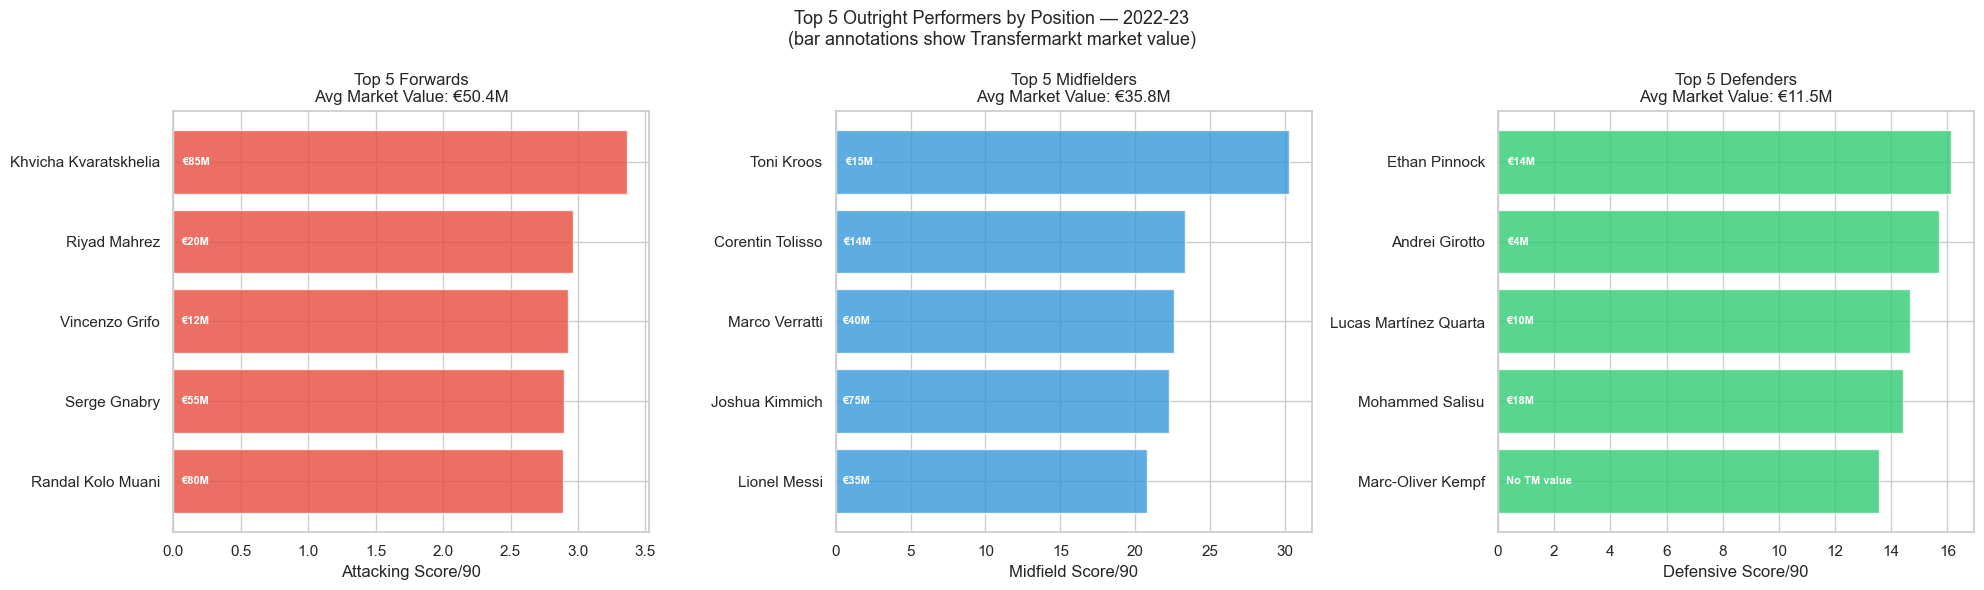

In [9]:
# Bar chart: top 5 performers per position with market value overlay
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
pos_colors_bar = {'FW': '#e74c3c', 'MF': '#3498db', 'DF': '#2ecc71'}

for ax, pos in zip(axes, ['FW', 'MF', 'DF']):
    grp = top5[top5['pos_group'] == pos].copy()
    avg_val = grp['avg_market_value_eur_M_top5'].iloc[0]

    bars = ax.barh(grp['Player'][::-1], grp['perf_score'][::-1],
                   color=pos_colors_bar[pos], alpha=0.8)
    ax.set_xlabel(pos_score_label[pos])
    ax.set_title(f'Top 5 {pos_labels[pos]}\nAvg Market Value: €{avg_val:.1f}M' if pd.notna(avg_val)
                 else f'Top 5 {pos_labels[pos]}')

    # Annotate bars with market value
    for bar, (_, row) in zip(bars[::-1], grp.iterrows()):
        val_str = f'€{row["market_value_eur_M"]:.0f}M' if pd.notna(row['market_value_eur_M']) else 'No TM value'
        ax.text(bar.get_width() * 0.02, bar.get_y() + bar.get_height() / 2,
                val_str, va='center', ha='left', fontsize=8, color='white', fontweight='bold')

plt.suptitle('Top 5 Outright Performers by Position — 2022-23\n(bar annotations show Transfermarkt market value)',
             fontsize=13)
plt.tight_layout()
plt.savefig('top5_performers.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Best Value Players by Position — Output per €M of Market Value

**Which players deliver the most performance relative to their Transfermarkt price?**

Value score = position-specific performance score ÷ market value in €M. Higher = more output per euro spent. Players are ranked **within their own position only** — defenders are never compared to forwards.

Results shown both unfiltered (all valuations) and filtered to ≥ €1M to remove stale/placeholder TM entries.

In [10]:
def top_value_table(data, n=10, min_value_m=0.0):
    cols = ['Player', 'Squad', 'Comp', 'Age', 'nineties', 'perf_score',
            'market_value_eur_M', 'value_score']
    return (
        data[(data['value_score'].notna()) & (data['market_value_eur_M'] >= min_value_m)]
        .nlargest(n, 'value_score')[cols]
        .rename(columns={'nineties': '90s', 'market_value_eur_M': 'Value (€M)',
                         'perf_score': 'Perf Score', 'value_score': 'Value Score'})
        .reset_index(drop=True)
    )

In [11]:
# Unfiltered top 10 (all valuations)
print('=== Top 10 Forwards — all valuations ===')
display(top_value_table(fw))

# Filtered: ≥€1M valuation for cleaner storytelling
MIN_VAL = 1.0
print(f'\n=== Top 10 Forwards — valuations ≥ €{MIN_VAL}M ===')
display(top_value_table(fw, min_value_m=MIN_VAL))

=== Top 10 Forwards — all valuations ===


,Player,Squad,Comp,Age,90s,Perf Score,Value (€M),Value Score
0,Jonas Hofmann,M'Gladbach,Bundesliga,30,15.600,2.607,0.150,17.378
1,Samuel,Valencia,La Liga,23,19.800,1.325,0.100,13.250
2,Álvaro García,Rayo Vallecano,La Liga,30,16.500,1.547,0.200,7.737
3,Willian,Fulham,Premier League,34,13.400,2.018,0.400,5.045
4,Adama Traoré,Wolves,Premier League,27,10.000,1.160,0.250,4.640
5,Luiz Henrique,Betis,La Liga,22,12.900,0.937,0.300,3.122
6,Antony,Manchester Utd,Premier League,22,10.100,1.238,0.600,2.063
7,Florian Niederlechner,Augsburg,Bundesliga,32,10.100,1.043,0.800,1.304
8,Simon Terodde,Schalke 04,Bundesliga,34,14.200,1.029,0.900,1.144
9,Nuno da Costa,Auxerre,Ligue 1,32,12.800,1.096,1.000,1.096



=== Top 10 Forwards — valuations ≥ €1.0M ===


,Player,Squad,Comp,Age,90s,Perf Score,Value (€M),Value Score
0,Nuno da Costa,Auxerre,Ligue 1,32,12.800,1.096,1.000,1.096
1,Kévin Gameiro,Strasbourg,Ligue 1,35,15.500,1.291,1.200,1.076
2,André Silva,RB Leipzig,Bundesliga,27,13.300,1.989,2.000,0.994
3,Pedro,Lazio,Serie A,35,12.400,1.392,1.500,0.928
4,Léo Baptistão,Almería,La Liga,30,10.500,1.503,1.800,0.835
5,Pedro,Lazio,Serie A,35,12.400,1.392,2.000,0.696
6,Amine Salama,Angers,Ligue 1,22,11.100,1.026,1.500,0.684
7,Willian,Fulham,Premier League,34,13.400,2.018,3.000,0.673
8,Federico Di Francesco,Lecce,Serie A,28,12.500,1.184,1.800,0.658
9,Renaud Ripart,Troyes,Ligue 1,29,11.200,1.585,2.500,0.634


In [12]:
print('=== Top 10 Midfielders — all valuations ===')
display(top_value_table(mf))
print(f'\n=== Top 10 Midfielders — valuations ≥ €{MIN_VAL}M ===')
display(top_value_table(mf, min_value_m=MIN_VAL))

=== Top 10 Midfielders — all valuations ===


,Player,Squad,Comp,Age,90s,Perf Score,Value (€M),Value Score
0,Mathieu Coutadeur,Ajaccio,Ligue 1,36,10.900,13.712,0.200,68.560
1,Fabinho,Liverpool,Premier League,29,13.900,11.155,0.200,55.775
2,Fabinho,Liverpool,Premier League,29,13.900,11.155,0.300,37.183
3,Jorginho,Chelsea,Premier League,31,14.200,13.260,0.400,33.150
4,Riad Nouri,Ajaccio,Ligue 1,37,13.500,5.301,0.200,26.505
5,Johan Gastien,Clermont Foot,Ligue 1,35,17.400,15.661,0.700,22.373
6,Fabinho,Liverpool,Premier League,29,13.900,11.155,0.600,18.592
7,Tomás Rincón,Sampdoria,Serie A,35,14.700,11.384,0.800,14.230
8,Christian Groß,Werder Bremen,Bundesliga,34,13.300,6.993,0.500,13.986
9,Mathias Autret,Auxerre,Ligue 1,31,13.200,11.007,0.800,13.759



=== Top 10 Midfielders — valuations ≥ €1.0M ===


,Player,Squad,Comp,Age,90s,Perf Score,Value (€M),Value Score
0,João Moutinho,Wolves,Premier League,36,15.500,14.649,1.500,9.766
1,João Moutinho,Wolves,Premier League,36,15.500,14.649,1.500,9.766
2,Florian Tardieu,Troyes,Ligue 1,30,11.200,15.650,2.000,7.825
3,Hamza Sakhi,Auxerre,Ligue 1,26,17.400,14.606,2.000,7.303
4,Mehdi Bourabia,Spezia,Serie A,31,18.500,9.046,1.300,6.958
5,Lassine Sinayoko,Auxerre,Ligue 1,23,13.200,7.669,1.200,6.391
6,Dani Rodríguez,Mallorca,La Liga,34,13.000,7.218,1.200,6.015
7,Xavier Chavalerin,Troyes,Ligue 1,31,15.000,8.289,1.500,5.526
8,Roque Mesa,Valladolid,La Liga,33,11.900,13.786,2.500,5.514
9,Kevin Stöger,Bochum,Bundesliga,29,17.200,14.695,3.000,4.898


In [13]:
print('=== Top 10 Defenders — all valuations ===')
display(top_value_table(df_pos))
print(f'\n=== Top 10 Defenders — valuations ≥ €{MIN_VAL}M ===')
display(top_value_table(df_pos, min_value_m=MIN_VAL))

=== Top 10 Defenders — all valuations ===


,Player,Squad,Comp,Age,90s,Perf Score,Value (€M),Value Score
0,David López,Girona,La Liga,33,10.400,8.940,0.050,178.800
1,Rogério,Sassuolo,Serie A,25,18.300,5.960,0.100,59.600
2,Joaquín Fernández,Valladolid,La Liga,26,14.600,10.410,0.175,59.486
3,Mohamed Youssouf,Ajaccio,Ligue 1,34,17.400,10.340,0.200,51.700
4,Danilo,Juventus,Serie A,31,20.100,9.500,0.200,47.500
5,Adam Smith,Bournemouth,Premier League,31,20.100,6.520,0.200,32.600
6,Cédric Avinel,Ajaccio,Ligue 1,36,12.200,7.960,0.250,31.840
7,Dodô,Fiorentina,Serie A,24,13.200,4.760,0.150,31.733
8,Federico Fazio,Salernitana,Serie A,35,11.800,12.620,0.400,31.550
9,Marlon,Monza,Serie A,27,11.800,8.630,0.350,24.657



=== Top 10 Defenders — valuations ≥ €1.0M ===


,Player,Squad,Comp,Age,90s,Perf Score,Value (€M),Value Score
0,Maxime Le Marchand,Strasbourg,Ligue 1,33,14.400,11.250,1.000,11.250
1,Pedro Bigas,Elche,La Liga,32,14.200,9.230,1.000,9.230
2,Tim Ream,Fulham,Premier League,35,23.000,8.560,1.000,8.560
3,Damián Suárez,Getafe,La Liga,34,10.000,8.200,1.000,8.200
4,Vincent Le Goff,Lorient,Ligue 1,33,22.000,7.960,1.000,7.960
5,Joel Ward,Crystal Palace,Premier League,33,14.400,9.440,1.200,7.867
6,Luis Hernández,Cádiz,La Liga,33,19.000,7.840,1.000,7.840
7,Niko Gießelmann,Union Berlin,Bundesliga,31,10.500,6.850,1.000,6.850
8,Stefan Bell,Mainz 05,Bundesliga,31,12.700,13.230,2.000,6.615
9,Marvin Plattenhardt,Hertha BSC,Bundesliga,31,13.600,6.610,1.000,6.610


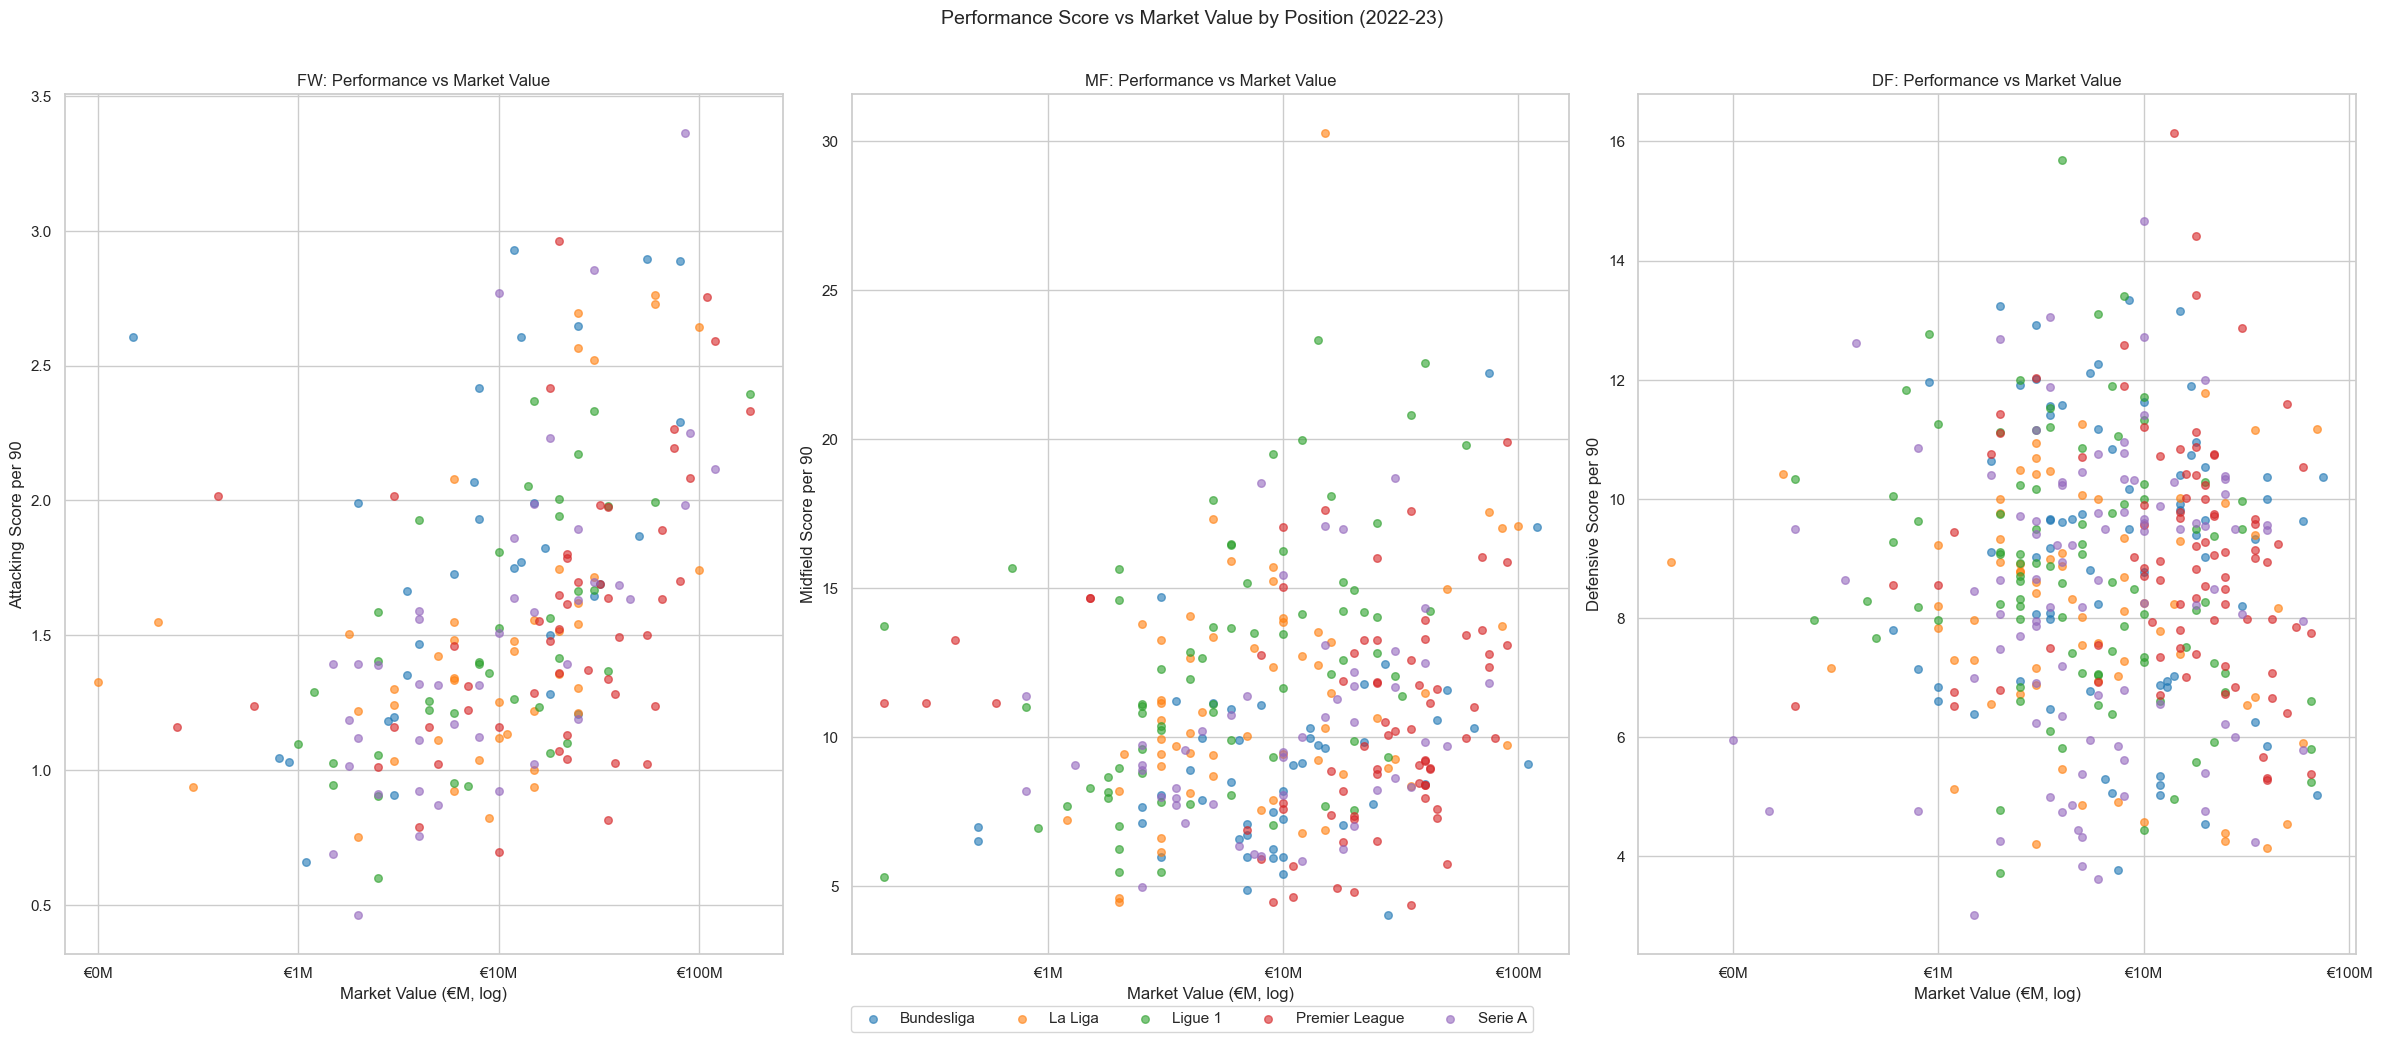

In [14]:
# Scatter: Performance Score vs Market Value, coloured by league
fig, axes = plt.subplots(1, 3, figsize=(24,10))
pos_data = [
    ('FW', fw, 'Attacking Score per 90'),
    ('MF', mf, 'Midfield Score per 90'),
    ('DF', df_pos, 'Defensive Score per 90'),
]
leagues = sorted(all_scored['Comp'].unique())
palette = sns.color_palette('tab10', n_colors=len(leagues))
lc = {l: palette[i] for i, l in enumerate(leagues)}

for ax, (pos, data, ylabel) in zip(axes, pos_data):
    valid = data[data['value_score'].notna()]
    for league in leagues:
        sub = valid[valid['Comp'] == league]
        ax.scatter(sub['market_value_eur_M'], sub['perf_score'],
                   label=league, alpha=0.6, s=30, color=lc[league])
    ax.set_xscale('log')
    ax.set_xlabel('Market Value (€M, log)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{pos}: Performance vs Market Value')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:.0f}M'))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Performance Score vs Market Value by Position (2022-23)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('perf_vs_value_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. League Comparison

In [15]:
league_sum = pd.read_sql('SELECT * FROM v_league_summary', conn)
display(league_sum)

,league,pos_group,player_count,avg_perf_score,avg_value_score,avg_market_value_eur_M
0,La Liga,DF,68,8.110,6.018,11.130
1,Ligue 1,DF,88,8.733,4.135,9.170
2,Serie A,DF,91,8.308,3.883,10.170
3,Bundesliga,DF,70,9.017,2.209,12.930
4,Premier League,DF,85,9.056,1.661,20.740
5,Bundesliga,FW,31,1.807,0.852,17.720
6,La Liga,FW,43,1.506,0.724,18.220
7,Premier League,FW,51,1.561,0.326,34.180
8,Ligue 1,FW,38,1.487,0.249,18.150
9,Serie A,FW,41,1.507,0.234,19.820


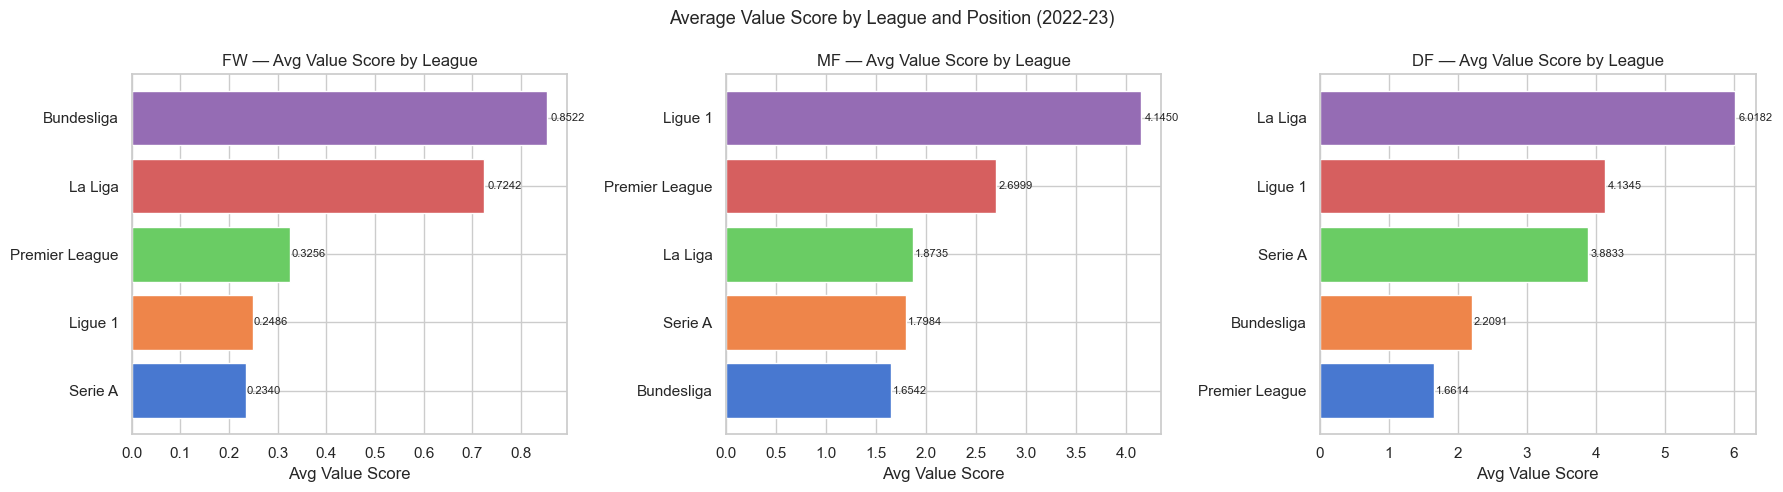

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, pos in zip(axes, ['FW', 'MF', 'DF']):
    sub = league_sum[league_sum['pos_group'] == pos].sort_values('avg_value_score', ascending=True)
    bars = ax.barh(sub['league'], sub['avg_value_score'],
                   color=sns.color_palette('muted', len(sub)))
    ax.set_title(f'{pos} — Avg Value Score by League')
    ax.set_xlabel('Avg Value Score')
    for bar, val in zip(bars, sub['avg_value_score']):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
plt.suptitle('Average Value Score by League and Position (2022-23)', fontsize=13)
plt.tight_layout()
plt.savefig('league_value_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Age Curves — Performance and Value by Age Band

In [17]:
age_sum = pd.read_sql('SELECT * FROM v_age_band_summary', conn)
age_order = ['U21', '21-25', '26-29', '30+']
age_sum['age_band'] = pd.Categorical(age_sum['age_band'], categories=age_order, ordered=True)
age_sum = age_sum.sort_values(['pos_group', 'age_band'])
display(age_sum)

,age_band,pos_group,player_count,avg_perf_score,avg_value_score,avg_market_value_eur_M
0,U21,DF,13,6.985,0.804,20.540
1,21-25,DF,150,8.680,1.955,17.790
2,26-29,DF,131,8.659,2.255,13.050
3,30+,DF,108,8.795,7.622,4.740
4,U21,FW,5,1.562,0.099,25.600
5,21-25,FW,78,1.578,0.342,35.370
6,26-29,FW,66,1.525,0.250,17.690
7,30+,FW,55,1.584,0.900,9.520
8,U21,MF,11,11.218,0.555,53.640
9,21-25,MF,105,10.067,0.978,23.710


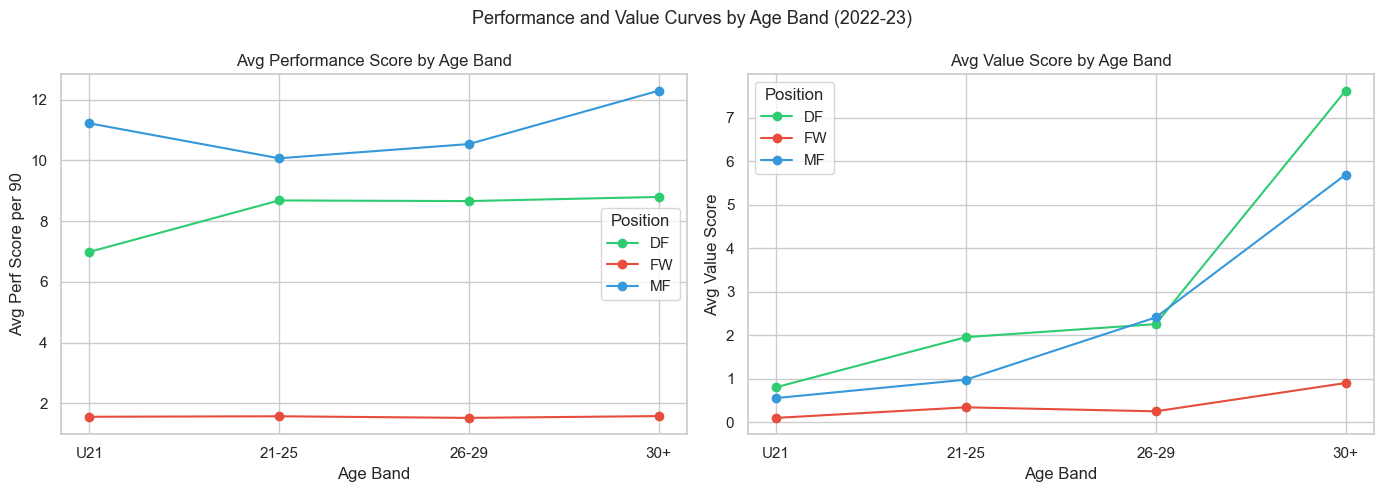

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pos_colors = {'FW': '#e74c3c', 'MF': '#3498db', 'DF': '#2ecc71'}

for pos, grp in age_sum.groupby('pos_group'):
    c = pos_colors.get(pos, 'grey')
    axes[0].plot(grp['age_band'], grp['avg_perf_score'], marker='o', label=pos, color=c)
    axes[1].plot(grp['age_band'], grp['avg_value_score'], marker='o', label=pos, color=c)

for ax, title, ylabel in zip(axes,
    ['Avg Performance Score by Age Band', 'Avg Value Score by Age Band'],
    ['Avg Perf Score per 90', 'Avg Value Score']):
    ax.set_title(title)
    ax.set_xlabel('Age Band')
    ax.set_ylabel(ylabel)
    ax.legend(title='Position')

plt.suptitle('Performance and Value Curves by Age Band (2022-23)', fontsize=13)
plt.tight_layout()
plt.savefig('age_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Correlation with Market Value

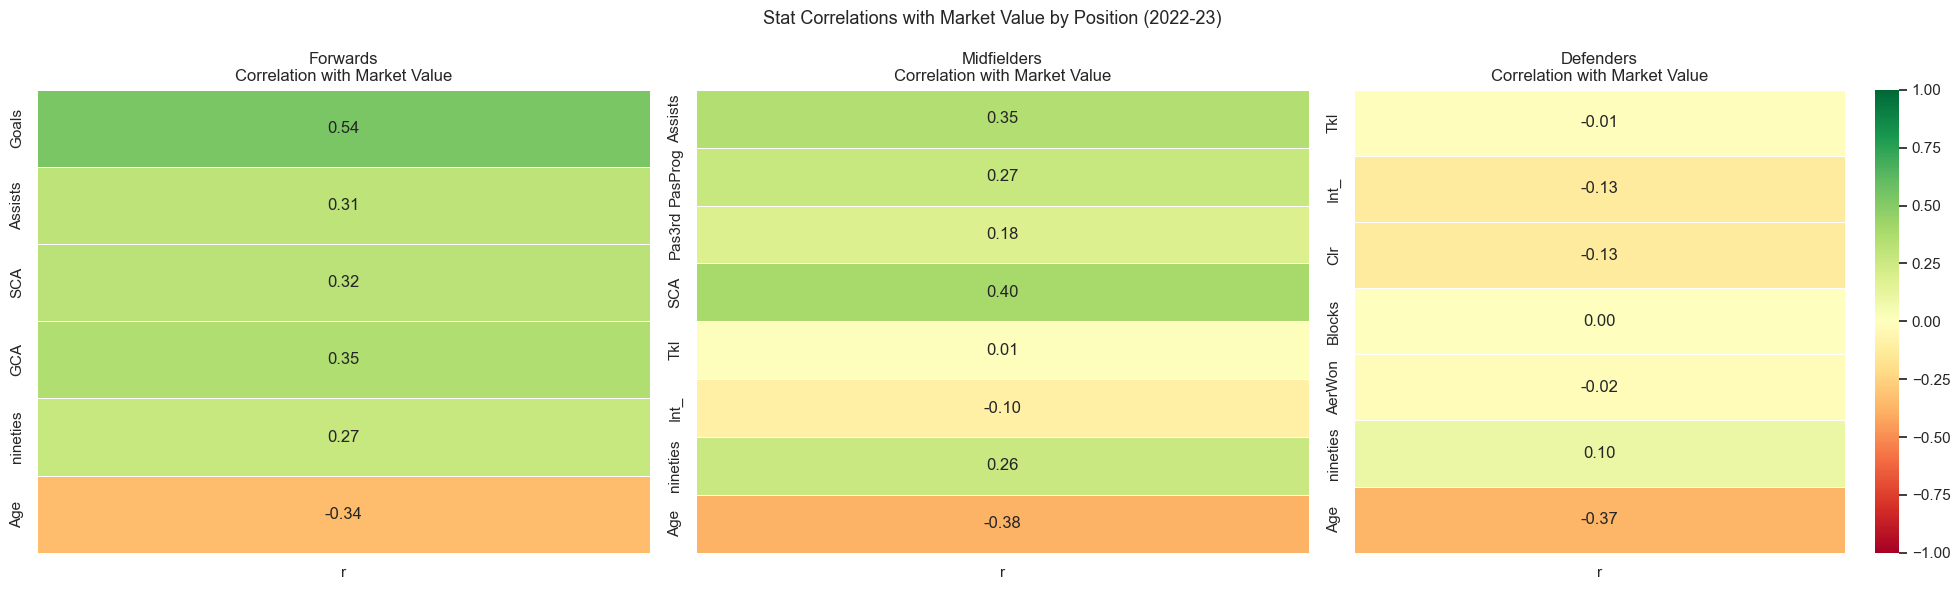

In [19]:
corr_specs = [
    (fw,     ['Goals','Assists','SCA','GCA','nineties','Age','market_value_in_eur'], 'Forwards'),
    (mf,     ['Assists','PasProg','Pas3rd','SCA','Tkl','Int_','nineties','Age','market_value_in_eur'], 'Midfielders'),
    (df_pos, ['Tkl','Int_','Clr','Blocks','AerWon','nineties','Age','market_value_in_eur'], 'Defenders'),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (data, cols, title) in zip(axes, corr_specs):
    valid = data[data['market_value_eur_M'].notna()][cols].dropna()
    mv_corr = (valid.corr()[['market_value_in_eur']]
                    .drop('market_value_in_eur')
                    .rename(columns={'market_value_in_eur': 'r'}))
    sns.heatmap(mv_corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=-1, vmax=1, cbar=(ax == axes[2]), linewidths=0.5)
    ax.set_title(f'{title}\nCorrelation with Market Value')
    ax.set_ylabel('')

plt.suptitle('Stat Correlations with Market Value by Position (2022-23)', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
for data, cols, pos in corr_specs:
    valid = data[data['market_value_eur_M'].notna()][cols].dropna()
    top3 = valid.corr()['market_value_in_eur'].drop('market_value_in_eur').abs().nlargest(3)
    print(f'{pos} — top 3 correlates with market value: {list(top3.index)}')

Forwards — top 3 correlates with market value: ['Goals', 'GCA', 'Age']
Midfielders — top 3 correlates with market value: ['SCA', 'Age', 'Assists']
Defenders — top 3 correlates with market value: ['Age', 'Clr', 'Int_']


---
## 9. Aggression & Discipline

> **Note on context:** Defenders commit more fouls as part of their defensive role — the baseline is structurally higher. An aggressive forward fouling > 2 times per 90 is a more unusual finding than the same rate in a centre-back. This section is kept separate from the value-score narrative and is its own analytical thread.

In [21]:
aggression = pd.read_sql('SELECT * FROM v_aggression', conn)

print('Position-group aggression baselines:')
display(aggression.groupby('primary_pos')[['fouls_per90','card_rate_per90']].agg(['mean','median']).round(3))

Position-group aggression baselines:


fouls_per90        card_rate_per90       
                   mean median            mean median
primary_pos                                          
DF                1.009  0.970           0.225  0.210
FW                1.242  1.200           0.180  0.160
MF                1.347  1.260           0.225  0.195

In [22]:
print('=== Top 10 Most Fouling Players (overall) ===')
display(
    aggression[['Player','Squad','Comp','primary_pos','nineties','Fls','fouls_per90','card_rate_per90']]
    .nlargest(10, 'fouls_per90').reset_index(drop=True)
)

=== Top 10 Most Fouling Players (overall) ===


,Player,Squad,Comp,primary_pos,nineties,Fls,fouls_per90,card_rate_per90
0,Érik Lamela,Sevilla,La Liga,FW,13.500,3.560,3.560,0.660
1,Gavi,Barcelona,La Liga,MF,14.100,3.400,3.400,0.280
2,Óscar Trejo,Rayo Vallecano,La Liga,MF,13.400,3.210,3.210,0.600
3,Alex Baena,Villarreal,La Liga,MF,11.500,3.130,3.130,1.050
4,Óscar Valentín,Rayo Vallecano,La Liga,MF,13.600,3.010,3.010,0.440
5,Mounaim El Idrissy,Ajaccio,Ligue 1,FW,17.700,2.820,2.820,0.400
6,Fede San Emeterio,Cádiz,La Liga,MF,10.800,2.780,2.780,0.460
7,Grejohn Kyei,Clermont Foot,Ligue 1,FW,12.000,2.750,2.750,0.170
8,Mikel Merino,Real Sociedad,La Liga,MF,14.300,2.730,2.730,0.280
9,Yeremi Pino,Villarreal,La Liga,MF,12.400,2.660,2.660,0.240


In [23]:
print('=== Top 5 Most Fouling Players per Position ===')
top_fouls = (
    aggression.sort_values('fouls_per90', ascending=False)
    .groupby('primary_pos').head(5)
    [['Player','Squad','Comp','primary_pos','nineties','fouls_per90','card_rate_per90']]
    .sort_values(['primary_pos','fouls_per90'], ascending=[True, False])
    .reset_index(drop=True)
)
display(top_fouls)

=== Top 5 Most Fouling Players per Position ===


,Player,Squad,Comp,primary_pos,nineties,fouls_per90,card_rate_per90
0,Giorgio Scalvini,Atalanta,Serie A,DF,13.700,2.550,0.360
1,Alessandro Buongiorno,Torino,Serie A,DF,15.700,2.420,0.380
2,Federico Ceccherini,Hellas Verona,Serie A,DF,11.500,2.260,0.790
3,Hugo Mallo,Celta Vigo,La Liga,DF,13.400,2.240,0.220
4,Isak Hien,Hellas Verona,Serie A,DF,15.800,2.220,0.440
5,Érik Lamela,Sevilla,La Liga,FW,13.500,3.560,0.660
6,Mounaim El Idrissy,Ajaccio,Ligue 1,FW,17.700,2.820,0.400
7,Grejohn Kyei,Clermont Foot,Ligue 1,FW,12.000,2.750,0.170
8,Lorenzo Colombo,Lecce,Serie A,FW,11.000,2.550,0.360
9,Anthony Lozano,Cádiz,La Liga,FW,12.700,2.520,0.240


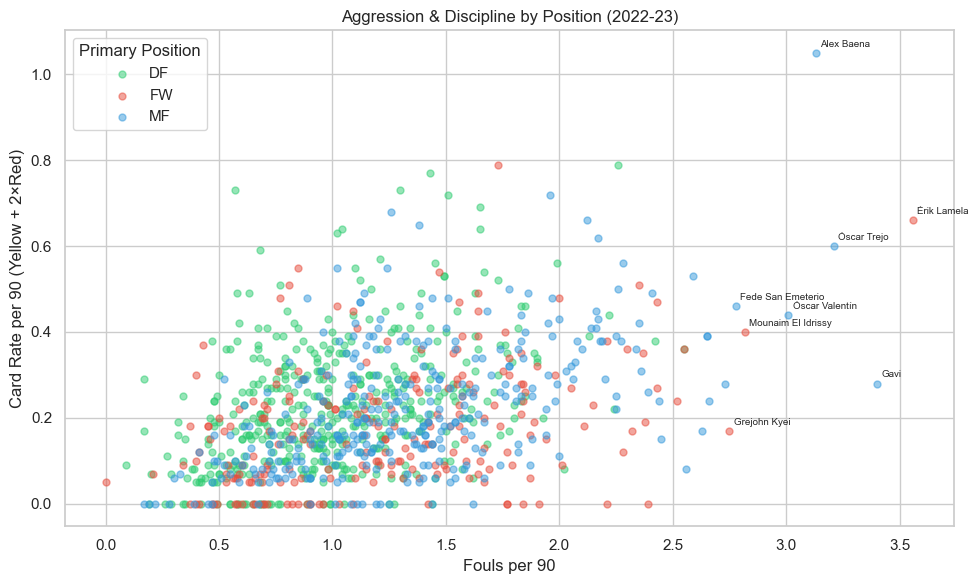

In [24]:
# Scatter: fouls_per90 vs card_rate_per90
fig, ax = plt.subplots(figsize=(10, 6))
pos_palette = {'FW': '#e74c3c', 'MF': '#3498db', 'DF': '#2ecc71'}
for pos, grp in aggression.groupby('primary_pos'):
    ax.scatter(grp['fouls_per90'], grp['card_rate_per90'],
               label=pos, alpha=0.5, s=25, color=pos_palette.get(pos, 'grey'))

for _, row in aggression.nlargest(8, 'fouls_per90').iterrows():
    ax.annotate(row['Player'], (row['fouls_per90'], row['card_rate_per90']),
                fontsize=7, ha='left', va='bottom', xytext=(3,3), textcoords='offset points')

ax.set_xlabel('Fouls per 90')
ax.set_ylabel('Card Rate per 90 (Yellow + 2×Red)')
ax.set_title('Aggression & Discipline by Position (2022-23)')
ax.legend(title='Primary Position')
plt.tight_layout()
plt.savefig('aggression_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/y_/02qd8mcj2_1cxz4yb61lffhr0000gn/T/ipykernel_43565/1774986074.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=aggression, x='primary_pos', y=col,
/var/folders/y_/02qd8mcj2_1cxz4yb61lffhr0000gn/T/ipykernel_43565/1774986074.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=aggression, x='primary_pos', y=col,


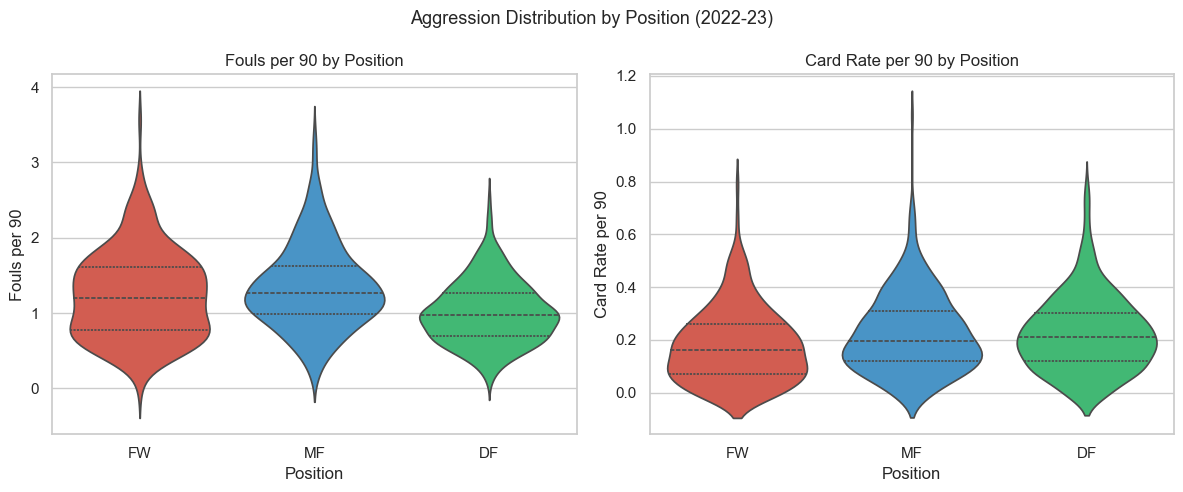

In [25]:
# Violin plots: fouls and card rate distributions by position
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = ['FW', 'MF', 'DF']
for ax, col, title, ylabel in zip(axes,
    ['fouls_per90', 'card_rate_per90'],
    ['Fouls per 90 by Position', 'Card Rate per 90 by Position'],
    ['Fouls per 90', 'Card Rate per 90']):
    sns.violinplot(data=aggression, x='primary_pos', y=col,
                   order=order, palette=pos_palette, inner='quartile', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Position')
    ax.set_ylabel(ylabel)

plt.suptitle('Aggression Distribution by Position (2022-23)', fontsize=13)
plt.tight_layout()
plt.savefig('aggression_violins.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Key Findings


**Preliminary findings from the data:**

- **Match rate:** 87.8% of eligible players (≥10 90s, non-GK) were name-matched to Transfermarkt; 83.6% had an end-of-season valuation in the 2022-23 window. ~16% are excluded from value ranking due to missing TM data — mostly squad/fringe players. Notable unmatched names include Pierre Højbjerg, Kim Min-jae, and Vinicius Júnior (encoding or name-form mismatches).
- **Low-valuation distortion:** Players with TM valuations below €1M dominate the raw value_score leaderboard despite modest per-90 output — their TM entries are often stale or placeholder figures. The ≥€1M filtered tables are more meaningful for storytelling and are the recommended lens for this analysis.
- **La Liga produces the most "undervalued" players** by position-adjusted score across FW, DF, and MF, reflecting generally lower market values relative to the level of on-pitch output. Premier League averages are highest in market value but lowest in value score — predictably expensive.
- **Value peaks in the 30+ age band** for all three positions. Older players with lower TM valuations but sustained per-90 output score highest. This reinforces the value-score's sensitivity to valuation — experienced players on low market values are the metric's natural winners.
- **Aggression by position:** Midfielders actually commit the most fouls per 90 on average (~1.35/90), followed closely by forwards (~1.24/90), with defenders lowest (~1.01/90). This challenges the assumption that defenders are structurally more aggressive — midfielders pressing high and forwards pressing are the most fouling groups. The top individual foulers (Lamela 3.56/90, Gavi 3.40/90, Óscar Trejo 3.21/90) are predominantly midfielders and forwards.
- **Correlation with market value** differs meaningfully by position: for forwards, `Goals` and `GCA` drive market value most; for midfielders, `SCA` and `Assists`; for defenders, `Age` and `Clr` — suggesting TM valuations for defenders are influenced more by experience/age profile than raw counting stats.

In [26]:
conn.close()
print('Analysis complete.')

Analysis complete.
